In [67]:
setwd('/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb')
library(data.table)
library(ggplot2)
library(ggrepel)
library(stringr)
devtools::load_all('utils/modules/R/gwastools')

i Loading gwastools

Warning message in setup_ns_exports(path, export_all, export_imports):
"Objects listed as exports, but not present in namespace: summarize_bcftools_trio_stats"


In [129]:
files <- list.files('data/simulation/saige/step2', pattern = ".txt$", full.names = TRUE)

In [130]:
ribbon_p <- 0.95
d <- do.call(rbind, lapply(files, function(f){
    d <- fread(f)
    d$p.value.expt <- get_expected_p(d$p.value, na.rm = TRUE)
    n <- length(d$p.value)
    dt <- data.table(
        ensembl_gene_id = d$MarkerID[order(d$p.value)],
        pvalue.observed = -log10(sort(d$p.value)),
        pvalue.expected = -log10(sort(d$p.value.expt)),
        clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
        cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
        iteration = gsub('cts','',str_extract(f, "cts[0-9]+")),
        parameters = str_extract(f, "h2_.+chr21")
        
    )
    return(dt)
}))

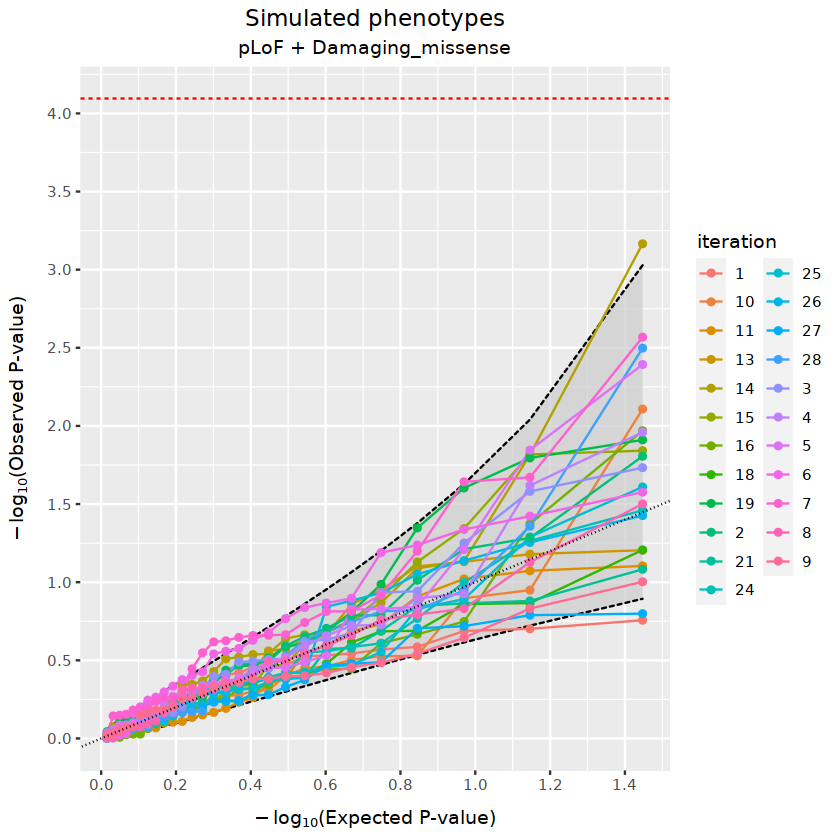

In [139]:
bonf <- 0.05 / (length(unique(d$ensembl_gene_id)) * length(unique(d$iteration)))
ggplot(d, aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, color = iteration)) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    geom_line() +
    geom_point() +
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    geom_hline(yintercept = -log10(bonf), linetype = 'dashed', color = 'red') +
    ggtitle("Simulated phenotypes", "pLoF + Damaging_missense") +
    theme(axis.title.x = element_text(margin=ggplot2::margin(t=10)),
          axis.title.y = element_text(margin=ggplot2::margin(r=10)),
          plot.title = element_text(hjust=0.5),
          plot.subtitle = element_text(hjust=0.5))

In [136]:
d$ensembe_gene_id

NULL

[1] 594

In [141]:
(length(unique(d$ensembl_gene_id)) * length(unique(d$iteration)))

[1] 621